### EXPLORATION DES DONNÉES SUR LA QUALITÉ DE L'AIR À *COTONOU*

* ### Polluants

***Les matières particulaires **(PM)** sont un indicateur indirect courant de la pollution de l’air. Il existe des données probantes solides sur les effets négatifs sur la santé de l’exposition aux matières particulaires. Les principaux composants en sont les sulfates, les nitrates, l’ammoniac, le chlorure de sodium, le carbone noir, la poussière minérale et l’eau.***

**Le monoxyde de carbone (CO):** est un gaz toxique incolore, inodore et insipide produit par la combustion incomplète de combustibles carbonés comme le bois, l’essence, le charbon de bois, le gaz naturel et le kérosène.

**L’ozone (O3) au niveau du sol:**  à ne pas confondre avec la couche d’ozone dans la haute atmosphère – est l’un des principaux constituants du smog photochimique. Il se forme lors de la réaction avec des gaz sous l’effet du rayonnement solaire.

**Le dioxyde d’azote (NO2)** est un gaz couramment libéré par les combustibles utilisés dans l’industrie et le secteur des transports.

**Le dioxyde de soufre (SO2)** est un gaz incolore, dont l’odeur est forte. Il est produit par la combustion d’énergies fossiles (charbon et pétrole) et la fonte de minerais contenant du soufre.



* ### Autres sur l'AIR

La pollution atmosphérique est l’un des plus grands risques environnementaux pour la santé. En diminuant les niveaux de pollution atmosphérique, les pays peuvent réduire la charge de morbidité imputable aux accidents vasculaires cérébraux, aux cardiopathies, au cancer du poumon et aux affections respiratoires, chroniques ou aiguës, y compris l’asthme.

**En 2019, 99 %** de la population mondiale vivaient dans des endroits où les seuils préconisés dans les lignes directrices de l’OMS relatives à la qualité de l’air n’étaient pas respectés.



Les effets combinés de la pollution de l’air ambiant et de la pollution de l’air intérieur sont associés à *6,7 millions de décès prématurés par an*.

*En 2019, on estimait à 4,2 millions* le nombre de décès prématurés provoqués par la pollution de l’air ambiant (extérieur) dans le monde.

Quelque *89 % de ces décès prématurés* sont survenus dans des pays à revenu faible ou intermédiaire, les Régions OMS de l’Asie du Sud-Est et du Pacifique occidental étant les plus touchées.
Il serait possible de réduire les principales sour

* ### 01- importation des librairies 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
import numpy as np
from dash import Dash
import plotly.express as px
from plotly.subplots import make_subplots
from plotly import graph_objects as go
import time
import warnings
warnings.filterwarnings("ignore")

%time

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 9.54 µs


#### Pathlib of dataset air quality

In [2]:
os.chdir(path="/home/donerick/Challenge 30 Days ML")

In [3]:
import pathlib
data_air = pd.read_csv(pathlib.Path('data/raw/hourly_quality_air_data.csv'))

data_air.head()

,date,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5
0,2025-09-30 00:00:00+00:00,44.200001,45.799999,657.0,470.0,2.8,40.0,11.2,NaN,1610.0,23.574997,23.574997
1,2025-09-30 01:00:00+00:00,51.299999,53.299999,657.0,471.0,4.6,40.0,14.1,NaN,1637.0,26.125000,26.125000
2,2025-09-30 02:00:00+00:00,42.700001,44.700001,554.0,465.0,3.8,41.0,12.3,NaN,1586.0,29.491669,29.491669
3,2025-09-30 03:00:00+00:00,39.000000,41.299999,394.0,456.0,2.8,41.0,9.7,NaN,1492.0,32.333332,32.333332
4,2025-09-30 04:00:00+00:00,31.100000,33.799999,270.0,449.0,2.0,42.0,7.6,NaN,1420.0,34.891666,34.891666


In [4]:
data_air.dtypes

date                   object
pm2_5                 float64
pm10                  float64
carbon_monoxide       float64
carbon_dioxide        float64
sulphur_dioxide       float64
ozone                 float64
nitrogen_dioxide      float64
formaldehyde          float64
methane               float64
european_aqi          float64
european_aqi_pm2_5    float64
dtype: object

In [5]:
data_air.columns

Index(['date', 'pm2_5', 'pm10', 'carbon_monoxide', 'carbon_dioxide',
       'sulphur_dioxide', 'ozone', 'nitrogen_dioxide', 'formaldehyde',
       'methane', 'european_aqi', 'european_aqi_pm2_5'],
      dtype='object')

In [6]:
data_air.shape

(4224, 12)

In [7]:
data_air.describe()

,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5
count,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,0.0,4224.000000,4224.000000,4224.000000
mean,19.059848,36.861127,244.539536,446.721591,0.892424,61.639915,2.719981,NaN,1377.817472,41.388654,38.683470
std,9.380960,24.376513,42.428582,5.532814,0.469263,18.703092,2.235710,NaN,29.753030,16.494518,14.707309
min,4.000000,6.600000,136.000000,432.000000,0.200000,18.000000,0.200000,NaN,1328.000000,17.600000,15.691666
25%,12.700000,21.500000,216.000000,444.000000,0.600000,48.000000,1.100000,NaN,1362.000000,28.863544,27.908339
50%,16.700001,29.200001,240.000000,447.000000,0.800000,59.000000,2.300000,NaN,1373.000000,35.200001,33.637497
75%,22.625000,43.725000,268.000000,450.000000,1.000000,71.000000,3.500000,NaN,1385.000000,50.739588,45.229166
max,100.800003,191.399994,657.000000,473.000000,6.500000,162.000000,27.000000,NaN,1654.000000,87.424995,79.173332


* ### 02- Valeurs Manquantes

In [8]:
def define_missing_values(data):
    missing_values = data.isnull().sum()
    ration_missing_values = missing_values / len(data) * 100
    missing_data = pd.DataFrame({
        "missing_values": missing_values,
        "ratio_missing_values": ration_missing_values
    })
    return missing_data.sort_values(by="ratio_missing_values", ascending=False)

missing_data_air_quality = define_missing_values(data_air)

In [9]:
missing_data_air_quality

,missing_values,ratio_missing_values
formaldehyde,4224,100.0
date,0,0.0
pm10,0,0.0
pm2_5,0,0.0
carbon_monoxide,0,0.0
carbon_dioxide,0,0.0
ozone,0,0.0
sulphur_dioxide,0,0.0
nitrogen_dioxide,0,0.0
methane,0,0.0


* ### 03- Visualisation Analytique avec **Plotly et Seaborn**

In [10]:
"""Avant de passer à la visualisation on va extraires quelques featires importantes des dates"""

data_air["date"] = pd.to_datetime(data_air["date"], utc=True)
df = data_air.sort_values("date").reset_index(drop=True)
 
df["hour"]      = df["date"].dt.hour
df["month"]     = df["date"].dt.month
df["dayofweek"] = df["date"].dt.dayofweek
df["date_str"]  = df["date"].dt.strftime("%Y-%m-%d")
df["month_str"] = df["date"].dt.strftime("%b %Y")
 
# Ratio PM2.5 / PM10 — signature de la source de pollution
df["pm_ratio"] = (df["pm2_5"] / df["pm10"].replace(0, np.nan)).round(3)

In [11]:
df.describe()

,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5,hour,month,dayofweek,pm_ratio
count,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,0.0,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000
mean,19.059848,36.861127,244.539536,446.721591,0.892424,61.639915,2.719981,NaN,1377.817472,41.388654,38.683470,11.500000,6.704545,2.988636,0.570992
std,9.380960,24.376513,42.428582,5.532814,0.469263,18.703092,2.235710,NaN,29.753030,16.494518,14.707309,6.923006,4.599603,2.000204,0.156146
min,4.000000,6.600000,136.000000,432.000000,0.200000,18.000000,0.200000,NaN,1328.000000,17.600000,15.691666,0.000000,1.000000,0.000000,0.226000
25%,12.700000,21.500000,216.000000,444.000000,0.600000,48.000000,1.100000,NaN,1362.000000,28.863544,27.908339,5.750000,2.000000,1.000000,0.448750
50%,16.700001,29.200001,240.000000,447.000000,0.800000,59.000000,2.300000,NaN,1373.000000,35.200001,33.637497,11.500000,10.000000,3.000000,0.556000
75%,22.625000,43.725000,268.000000,450.000000,1.000000,71.000000,3.500000,NaN,1385.000000,50.739588,45.229166,17.250000,11.000000,5.000000,0.682000
max,100.800003,191.399994,657.000000,473.000000,6.500000,162.000000,27.000000,NaN,1654.000000,87.424995,79.173332,23.000000,12.000000,6.000000,0.965000


#### Definir le niveau de la qualité d'air que nous consommons (selon OMS)

![air_quality_norms](/images/air_quality.png)

In [12]:
def indice_quality_air(data):

    """essayez de definir l'indice de la qualité d'air"""
    pm10 = data['pm10']
    pm2_5 = data['pm2_5']
    max_pm= max(pm10, pm2_5)
    if max_pm <=12:
        return "Bon"
    elif max_pm <= 35.5:
        return "Modéré"
    else:
        return "Mauvaise"
    
df["AQI"] = df.apply(lambda x: indice_quality_air(x), axis=1)
df.describe()

,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5,hour,month,dayofweek,pm_ratio
count,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,0.0,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000,4224.000000
mean,19.059848,36.861127,244.539536,446.721591,0.892424,61.639915,2.719981,NaN,1377.817472,41.388654,38.683470,11.500000,6.704545,2.988636,0.570992
std,9.380960,24.376513,42.428582,5.532814,0.469263,18.703092,2.235710,NaN,29.753030,16.494518,14.707309,6.923006,4.599603,2.000204,0.156146
min,4.000000,6.600000,136.000000,432.000000,0.200000,18.000000,0.200000,NaN,1328.000000,17.600000,15.691666,0.000000,1.000000,0.000000,0.226000
25%,12.700000,21.500000,216.000000,444.000000,0.600000,48.000000,1.100000,NaN,1362.000000,28.863544,27.908339,5.750000,2.000000,1.000000,0.448750
50%,16.700001,29.200001,240.000000,447.000000,0.800000,59.000000,2.300000,NaN,1373.000000,35.200001,33.637497,11.500000,10.000000,3.000000,0.556000
75%,22.625000,43.725000,268.000000,450.000000,1.000000,71.000000,3.500000,NaN,1385.000000,50.739588,45.229166,17.250000,11.000000,5.000000,0.682000
max,100.800003,191.399994,657.000000,473.000000,6.500000,162.000000,27.000000,NaN,1654.000000,87.424995,79.173332,23.000000,12.000000,6.000000,0.965000


In [13]:
df.AQI.value_counts()

AQI
Modéré      2577
Mauvaise    1546
Bon          101
Name: count, dtype: int64

In [14]:
df.head()

,date,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5,hour,month,dayofweek,date_str,month_str,pm_ratio,AQI
0,2025-09-30 00:00:00+00:00,44.200001,45.799999,657.0,470.0,2.8,40.0,11.2,NaN,1610.0,23.574997,23.574997,0,9,1,2025-09-30,Sep 2025,0.965,Mauvaise
1,2025-09-30 01:00:00+00:00,51.299999,53.299999,657.0,471.0,4.6,40.0,14.1,NaN,1637.0,26.125000,26.125000,1,9,1,2025-09-30,Sep 2025,0.962,Mauvaise
2,2025-09-30 02:00:00+00:00,42.700001,44.700001,554.0,465.0,3.8,41.0,12.3,NaN,1586.0,29.491669,29.491669,2,9,1,2025-09-30,Sep 2025,0.955,Mauvaise
3,2025-09-30 03:00:00+00:00,39.000000,41.299999,394.0,456.0,2.8,41.0,9.7,NaN,1492.0,32.333332,32.333332,3,9,1,2025-09-30,Sep 2025,0.944,Mauvaise
4,2025-09-30 04:00:00+00:00,31.100000,33.799999,270.0,449.0,2.0,42.0,7.6,NaN,1420.0,34.891666,34.891666,4,9,1,2025-09-30,Sep 2025,0.920,Modéré


In [15]:
# Agrégation journalière
NUM_COLS = ["pm2_5","pm10","carbon_monoxide","carbon_dioxide",
             "sulphur_dioxide","ozone","nitrogen_dioxide",
             "formaldehyde","methane","european_aqi","european_aqi_pm2_5"]


daily = (
    df.groupby("date_str")[NUM_COLS]
    .mean()
    .round(3)
    .reset_index()
)
 
# Profil horaire moyen
hourly_profile = (
    df.groupby("hour")[NUM_COLS]
    .mean()
    .round(3)
    .reset_index()
)
 
# Statistiques mensuelles
monthly = (
    df.groupby("month")[NUM_COLS]
    .mean()
    .round(2)
    .reset_index()
)
monthly["month_label"] = monthly["month"].map(
    {9:"Sept 2025", 10:"Oct 2025", 11:"Nov 2025", 12:"Déc 2025", 1:"Jan 2026", 2:"Fév 2026", 3:"Mar 2026"}
)
 
# Matrice corrélation
CORR_COLS = ["pm10","pm2_5","carbon_monoxide","sulphur_dioxide",
             "ozone","nitrogen_dioxide","formaldehyde","european_aqi"]
corr_short = {"pm10":"PM10","pm2_5":"PM2.5","carbon_monoxide":"CO",
              "sulphur_dioxide":"SO2","ozone":"O3","nitrogen_dioxide":"NO2",
              "formaldehyde":"CH2O","european_aqi":"AQI"}
corr_matrix = df[CORR_COLS].dropna().corr().round(3)
 
# Pics de pollution AQI > 60
peaks = (
    df[df["european_aqi"] > 60]
    .groupby("date_str")["european_aqi"]
    .max()
    .sort_values(ascending=False)
    .reset_index()
    .head(15)
)

In [16]:
AQI_COLORS = {
    "Bon":           "#1D9E75",
    "Modéré":         "#BA7517",
    "Mauvaise":       "#D85A30",
}

#### Distribution des NIveaux d'AQI

In [17]:
def fig_aqi_distribution() -> go.Figure:
    """Camembert des niveaux AQI + barres de comptage."""
    counts = df["AQI"].value_counts()
    ordre  = ["Bon","Moyen","Mauvaise"]
    labels = [l for l in ordre if l in counts.index]
    values = [counts[l] for l in labels]
    colors = [AQI_COLORS[l] for l in labels]
 
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "pie"}, {"type": "bar"}]],
        subplot_titles=["Répartition des heures", "Nombre d'heures par niveau"],
    )
 
    fig.add_trace(go.Pie(
        labels=labels, values=values,
        marker=dict(colors=colors),
        textinfo="percent+label",
        hovertemplate="%{label}<br><b>%{value} heures</b> (%{percent})<extra></extra>",
        hole=0.35,
    ), row=1, col=1)
 
    fig.add_trace(go.Bar(
        x=labels, y=values,
        marker_color=colors,
        text=values, textposition="outside",
        hovertemplate="%{x}<br><b>%{y} heures</b><extra></extra>",
    ), row=1, col=2)
 
    fig.update_layout(
        template="plotly_white", 
        height=320,
        margin=dict(l=10, r=10, t=30, b=10),
        showlegend=False,
    )
    return fig

In [18]:
fig_aqi_distribution()

In [19]:
POLLUTANT_META = {
    "pm2_5": "PM2.5 (μg/m³)",        
    "pm10":   "PM10 (μg/m³)",          
    "european_aqi":  "AQI Européen",          
    "carbon_monoxide": "CO (μg/m³)",            
    "ozone":  "Ozone O₃ (μg/m³)",      
    "nitrogen_dioxide":"NO₂ (μg/m³)",          
    "sulphur_dioxide": "SO₂ (μg/m³)",           
    "formaldehyde":    "Formaldéhyde (μg/m³)",  
    "methane":         "Méthane (μg/m³)",    
}

In [20]:
def fig_pm_scatter() -> go.Figure:
    """Scatter PM2.5 vs PM10 colorié par AQI, avec ligne de régression."""
    subset = df[["pm2_5", "pm10", "european_aqi", "hour", "AQI"]].dropna(
        subset=["pm2_5", "pm10", "european_aqi"]
    )

    sample = subset.sample(min(2000, len(subset)), random_state=42)

    fig = px.density_contour(
        sample, 
        x="pm10", 
        y="pm2_5",
        color="AQI",
        # title="Relation PM2.5 vs PM10 (densité)",
    )

    fig.add_trace(go.Scatter(
        x=sample["pm10"],
        y=sample["pm2_5"],
        mode="markers",
        marker=dict(size=3, opacity=0.3, color="gray"),
        showlegend=False
    ))

    # Ligne de tendance réelle (régression)
    z = np.polyfit(sample["pm10"], sample["pm2_5"], 1)
    p = np.poly1d(z)


    # Ligne PM2.5 = 0.44 × PM10 (ratio moyen observé)
    x_range = np.linspace(sample["pm10"].min(), sample["pm10"].max(), 50)
    fig.add_trace(go.Scatter(
        x=x_range, y=p(x_range),
        mode="lines",
        line=dict(color="red", dash="dash", width=2),
        name=f"Régression (y={z[0]:.2f}x+{z[1]:.2f})",
        hoverinfo="skip",
    ))

    fig.update_traces(marker=dict(size=4), selector=dict(mode="markers"))
    fig.update_layout(
        template="plotly_white", height=350,
        margin=dict(l=10, r=10, t=10, b=10),
        coloraxis_colorbar=dict(title="AQI", thickness=12, len=0.8),
    )
    return fig


In [21]:
fig_pm_scatter()

* ###  ==== RELATION DE PM2.5 AVEC LES AUTRES POLLUANTS et MATRIX DE CORRELATION ====

In [22]:

def fig_polluants(variable: str) -> go.Figure:
    """relation entre PM2.5 avec les autres polluants"""


    label = corr_short.get(variable, variable)
    subset = df[['pm2_5', variable]].dropna()

    # Nuage de points pour visualiser la relation entre deux variables continues
    fig = px.scatter(
        subset,
        x=variable,
        y="pm2_5",
        color=df['AQI'],
        opacity=0.65,
        render_mode="webgl",  # plus fluide quand beaucoup de points
        marginal_x="histogram",
        marginal_y="histogram",
    )
    
    fig.update_layout(
        template="plotly_white", height=320,
        margin=dict(l=10, r=10, t=10, b=10),
        showlegend=True,
        xaxis_title=label,
        yaxis_title="PM2.5",
        )

    return fig
#=======================HEATMAP GLOABLE=======================

def fig_correlation_heatmap() -> go.Figure:
    """Heatmap de corrélation des polluants."""
    available_corr_cols = [c for c in CORR_COLS if df[c].notna().any()]
    corr = df[available_corr_cols].corr().round(3)
    labels = [corr_short[c] for c in available_corr_cols]
    z    = corr_matrix.values
    text = [[f"{v:.2f}" for v in row] for row in z]

    fig = go.Figure(go.Heatmap(
        z=z, x=labels, y=labels,
        text=text, texttemplate="%{text}",
        textfont=dict(size=11),
        colorscale=[[0, 'blue'], [0.5, 'green'], [1.0, 'rgb(0, 0, 255)'],
        ],
        zmid=0, zmin=-1, zmax=1,
        colorbar=dict(title="correlation", thickness=12, len=0.8),
        hovertemplate="%{y} / %{x}<br><b>r = %{z:.3f}</b><extra></extra>",
    ))
    fig.update_layout(
        template="plotly_white", height=360,
        margin=dict(l=10, r=10, t=10, b=10),
        xaxis=dict(side="bottom"),
        yaxis=dict(autorange="reversed"),
    )
    return fig

In [23]:
fig_correlation_heatmap()

In [24]:
df.head()

,date,pm2_5,pm10,carbon_monoxide,carbon_dioxide,sulphur_dioxide,ozone,nitrogen_dioxide,formaldehyde,methane,european_aqi,european_aqi_pm2_5,hour,month,dayofweek,date_str,month_str,pm_ratio,AQI
0,2025-09-30 00:00:00+00:00,44.200001,45.799999,657.0,470.0,2.8,40.0,11.2,NaN,1610.0,23.574997,23.574997,0,9,1,2025-09-30,Sep 2025,0.965,Mauvaise
1,2025-09-30 01:00:00+00:00,51.299999,53.299999,657.0,471.0,4.6,40.0,14.1,NaN,1637.0,26.125000,26.125000,1,9,1,2025-09-30,Sep 2025,0.962,Mauvaise
2,2025-09-30 02:00:00+00:00,42.700001,44.700001,554.0,465.0,3.8,41.0,12.3,NaN,1586.0,29.491669,29.491669,2,9,1,2025-09-30,Sep 2025,0.955,Mauvaise
3,2025-09-30 03:00:00+00:00,39.000000,41.299999,394.0,456.0,2.8,41.0,9.7,NaN,1492.0,32.333332,32.333332,3,9,1,2025-09-30,Sep 2025,0.944,Mauvaise
4,2025-09-30 04:00:00+00:00,31.100000,33.799999,270.0,449.0,2.0,42.0,7.6,NaN,1420.0,34.891666,34.891666,4,9,1,2025-09-30,Sep 2025,0.920,Modéré


In [25]:
import matplotlib.pyplot as plt

def lag_analysis()-> go.Figure:
    lags = range(1, 25)
    corrs = [df["pm2_5"].corr(df["pm2_5"].shift(lag)) for lag in lags]

    fig_lag = px.line(
        data_frame=df,
        x=lags,
        y=corrs,
        title="Autocorrelation PM2.5"
    )

    fig_lag.update_traces(
        textposition="bottom right"
    )
    fig_lag.show()

lag_analysis()

Variance expliquée par composante :
  PC1 : 408.5%
  PC2 : 253.8%
  PC3 : 79.3%
  Total : 741.6%


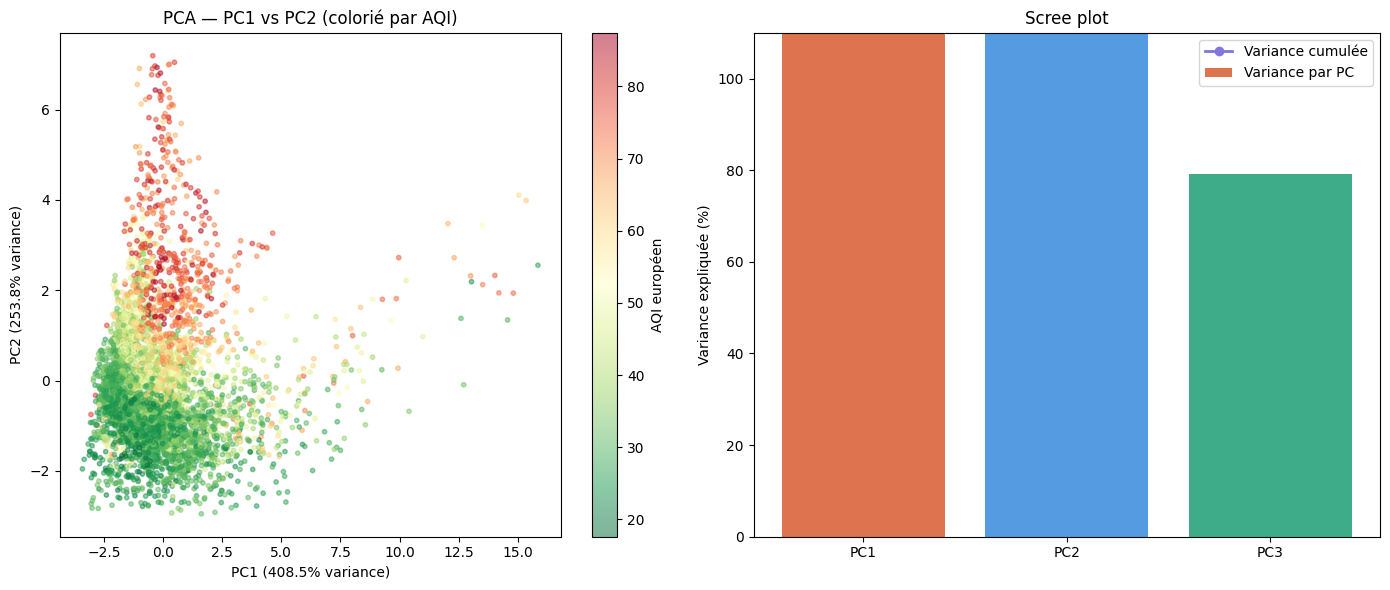

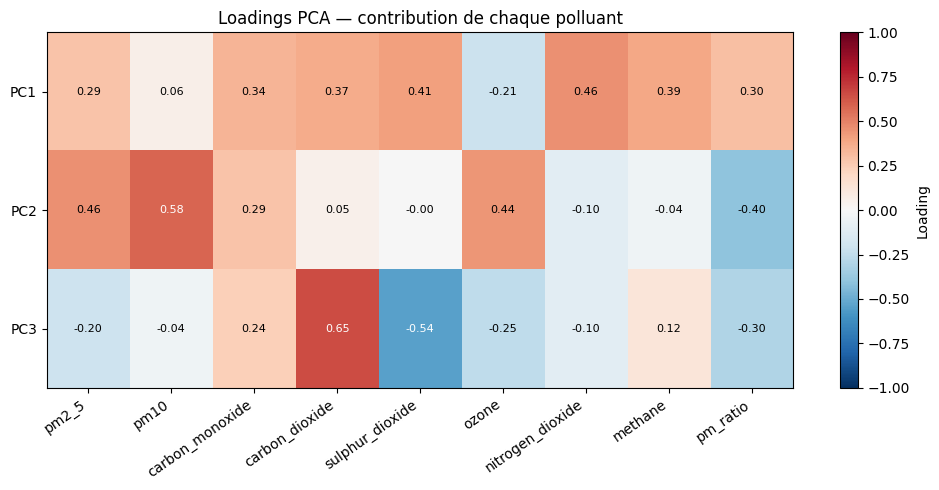

In [26]:
colonnes = ['pm2_5', "pm10", "carbon_monoxide", "carbon_dioxide", "sulphur_dioxide", "ozone",
            "nitrogen_dioxide", "methane", "pm_ratio"]

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

x = df[colonnes]
pca = PCA(n_components=3)
scaler = StandardScaler(with_mean=True)
x_scaler = scaler.fit_transform(x)

# pca

x_pca = pca.fit_transform(X=x_scaler)
components = pca.components_
variance_explained = pca.explained_variance_


print("Variance expliquée par composante :")
for i, v in enumerate(variance_explained):
    print(f"  PC{i+1} : {v:.1%}")
print(f"  Total : {sum(variance_explained):.1%}")

# Étape 5 : Scatter PC1 vs PC2 
# 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Colorier par AQI si disponible
color_col = df.loc[x.index, "european_aqi"] if "european_aqi" in df.columns else None

sc = axes[0].scatter(
    x=x_pca[:, 0],
    y=x_pca[:, 1],
    c=color_col,
    cmap="RdYlGn_r",
    alpha=0.5,
    s=10,
)
axes[0].set_xlabel(f"PC1 ({variance_explained[0]:.1%} variance)")
axes[0].set_ylabel(f"PC2 ({variance_explained[1]:.1%} variance)")
axes[0].set_title("PCA — PC1 vs PC2 (colorié par AQI)")
if color_col is not None:
    plt.colorbar(sc, ax=axes[0], label="AQI européen")


cumvar = np.cumsum(variance_explained)
axes[1].bar(
    [f"PC{i+1}" for i in range(len(variance_explained))],
    variance_explained * 100,
    color=["#D85A30", "#378ADD", "#1D9E75"],
    alpha=0.85,
    label="Variance par PC"
)
axes[1].plot(
    [f"PC{i+1}" for i in range(len(variance_explained))],
    cumvar * 100,
    marker="o", color="#7F77DD", linewidth=2, label="Variance cumulée"
)
axes[1].set_ylabel("Variance expliquée (%)")
axes[1].set_title("Scree plot")
axes[1].legend()
axes[1].set_ylim(0, 110)

plt.tight_layout()
plt.show()

# Étape 7 : Loading plot — contribution de chaque variable ──
fig2, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    pca.components_,
    cmap="RdBu_r",
    aspect="auto", 
    vmin=-1, vmax=1
)
ax.set_xticks(range(len(colonnes)))
ax.set_xticklabels(colonnes, rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(3))
ax.set_yticklabels(["PC1", "PC2", "PC3"])
ax.set_title("Loadings PCA — contribution de chaque polluant")
plt.colorbar(im, ax=ax, label="Loading")

# Annoter les valeurs
for i in range(3):
    for j in range(len(colonnes)):
        ax.text(j, i, f"{pca.components_[i, j]:.2f}",
                ha="center", va="center", fontsize=8,
                color="white" if abs(pca.components_[i, j]) > 0.5 else "black")

plt.tight_layout()
plt.show()